# Assignemt 01 - Sentiment Analysis

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

### Sentiment Analysis Using TF-IDF Vectors

**Objective:**  
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

### Dataset Description for Sentiment Analysis Project

**Content:**  
The dataset is stored in a **CSV file** and includes six fields:

1. **Polarity (Column 0):**  
   - Sentiment label for the tweet:  
     - `0`: Negative sentiment  
     - `2`: Neutral sentiment  
     - `4`: Positive sentiment

2. **Tweet ID (Column 1):**  
   - A unique identifier for each tweet.

3. **Date (Column 2):**  
   - The timestamp of when the tweet was posted, in the format:  
     `Day Month Date HH:MM:SS UTC Year`  
     *(e.g., Sat May 16 23:58:44 UTC 2009)*

4. **Query (Column 3):**  
   - The search query used to retrieve the tweet.  
     If no query was used, the value is `NO_QUERY`.

5. **User (Column 4):**  
   - The username of the account that posted the tweet  
     *(e.g., robotickilldozr)*

6. **Text (Column 5):**  
   - The content of the tweet, consisting of raw text after emoticons have been removed  
     *(e.g., Lyx is cool)*

Dataset Source on Kaggle
  </p>
</details>

## Notes & Remarks

Basic EDA shows the following:

- `train_data.csv` has no `neutral`  or `2` in polarity, Moreover the data is not very balanced which would affect the training process. Read more about this data in Kaggle to understand how it is built.
- `train.csv` and `test.csv` are more balanced. However, it is a much smaller dataset.
- No sure if concatenating both datasets is a good option, or simply taking the smaller dataset alone...

[9/22/2025]

- Considering joining both datasets and resampling to deal with the imbalanced nature of the dataset --> too small?

## To Do List

- [ ] Do a deeper analysis of the datasets using word count, lemmas, etc...

## Imports

In [36]:
# import kagglehub
import pandas as pd
import html
import re

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import spacy

import warnings
warnings.filterwarnings('ignore')

## Download

In [2]:
# Download latest version
# path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

# print("Path to dataset files:", path)

## Read + EDA

The files were renamed from the original Kaggle form:
- train --> train.csv
- test --> test.csv
- training_processed_noemoticon --> train_data.csv
- testdata_manual_2009-06-14 --> test_data.csv


In [3]:
# get the encoding of the data to read properly
import chardet

# Path to the file
file_path = '../Data/train_data.csv'

# Read the entire file in binary mode
with open(file_path, 'rb') as f:
    raw_data = f.read()

# Detect encoding using chardet
result = chardet.detect(raw_data)

# Print the best guess encoding and confidence
print(f"Best guess encoding: {result['encoding']}")
print(f"Confidence score: {result['confidence']}")

Best guess encoding: Windows-1252
Confidence score: 0.7296742189906609


In [8]:
train_df = pd.read_csv("../Data/train_data.csv", encoding="Windows-1252")

# Clean column names
train_df.columns = [html.unescape(col).replace('\xa0', ' ').strip() for col in train_df.columns]

# Rename the cleaned columns
train_df.rename(columns={
    'polarity of tweet': 'polarity',
    'id of the tweet' : 'id',
    'date of the tweet' : 'date',
    'text of the tweet' : 'text'
}, inplace=True)

cols = train_df.columns.to_list()

# Has no header
test_df = pd.read_csv("../Data/test_data.csv", header=None, names=cols)

In [9]:
train_df.head()

,polarity,id,date,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [10]:
test_df.head()

,polarity,id,date,query,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...


focus only on necessary info

In [11]:
train_df = train_df[["text", "polarity"]]
test_df = test_df[["text", "polarity"]]

check for duplicates

In [12]:
has_duplicates = train_df.duplicated().any()
print("train_df has duplicates:", has_duplicates)
has_duplicates = test_df.duplicated().any()
print("test_df has duplicates:", has_duplicates)

train_df has duplicates: True
test_df has duplicates: True


Example of a duplicate

In [13]:
train_df[train_df["text"]==train_df["text"][1047517]]

,text,polarity
1047517,TODAY IS #nobitchassnessfriday GIVE A HATER A ...,4
1048238,TODAY IS #nobitchassnessfriday GIVE A HATER A ...,4


check for Nans

In [14]:
print("train Nans")
print(train_df.isnull().sum())
print("test Nans")
print(test_df.isnull().sum())

train Nans
text        0
polarity    0
dtype: int64
test Nans
text        0
polarity    0
dtype: int64


do basic text cleaning

In [15]:
def basic_text_clean(text):
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = text.strip()
    return text

In [16]:
train_df["text"] = train_df["text"].apply(basic_text_clean)
test_df["text"] = test_df["text"].apply(basic_text_clean)

clean duplicates after clean text ... leads to more rows dropped

In [17]:
before = len(train_df)
train_df.drop_duplicates(inplace=True)
print(f"{before - len(train_df)} rows are dropped")
before = len(test_df)
test_df.drop_duplicates(inplace=True)
print(f"{before - len(test_df)} rows are dropped")

15020 rows are dropped
18 rows are dropped


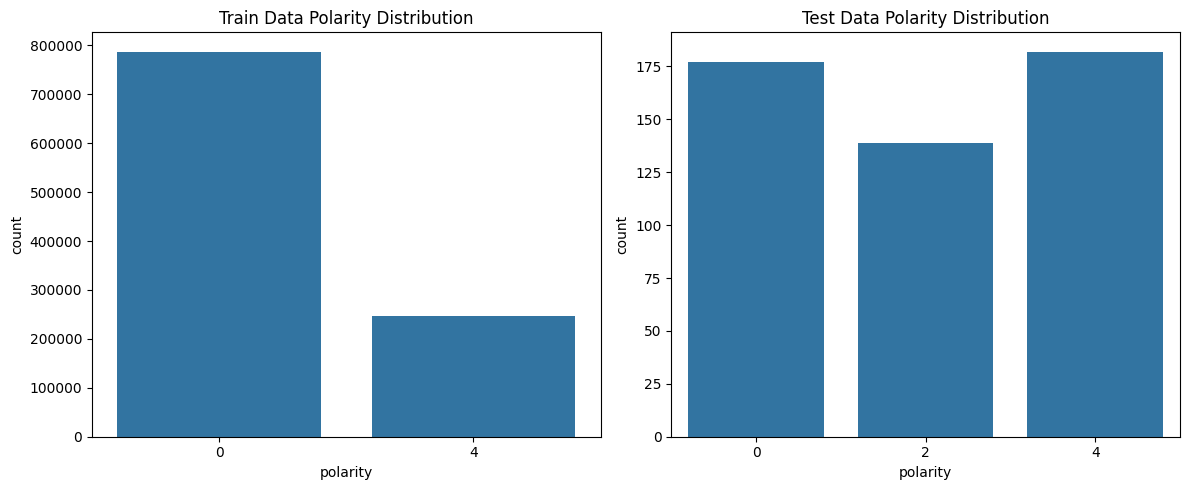

In [18]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train data polarity distribution
sns.countplot(data=train_df, x="polarity", ax=axes[0])
axes[0].set_title("Train Data Polarity Distribution")

# Test data polarity distribution
sns.countplot(data=test_df, x="polarity", ax=axes[1])
axes[1].set_title("Test Data Polarity Distribution")

plt.tight_layout()

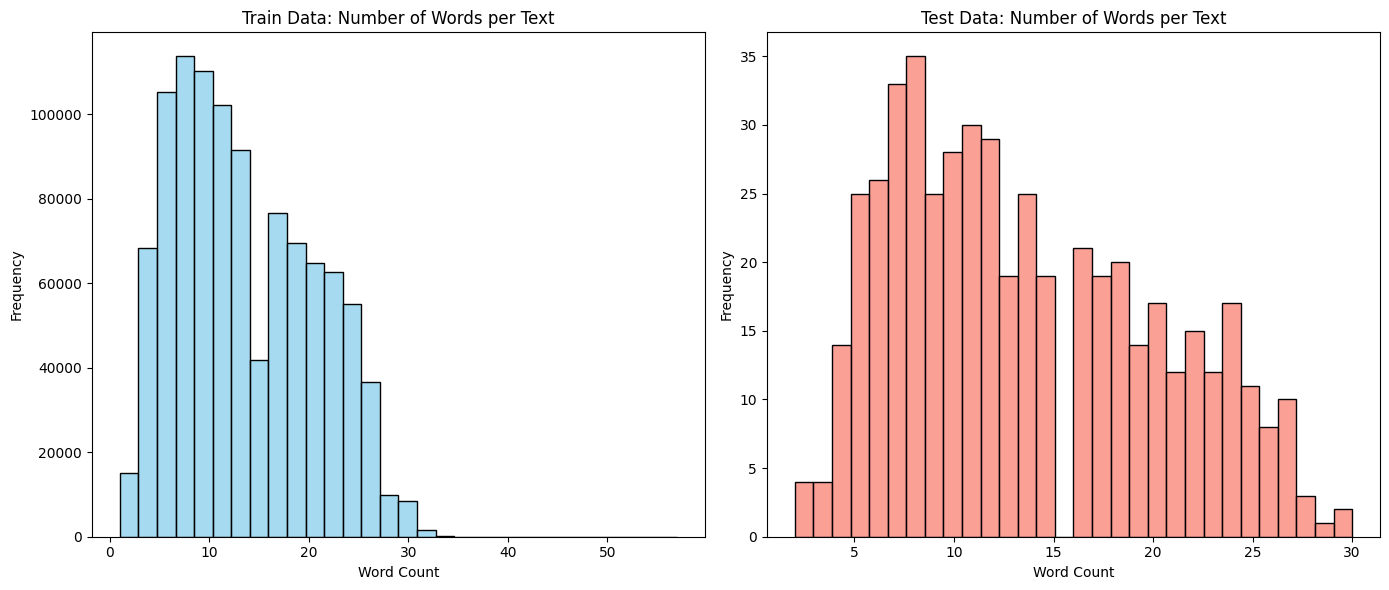

In [19]:
# Calculate word counts
train_word_counts = train_df['text'].astype(str).apply(lambda x: len(x.split()))
test_word_counts = test_df['text'].astype(str).apply(lambda x: len(x.split()))

# Create side-by-side histograms with separate y-axis scales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(train_word_counts, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Train Data: Number of Words per Text')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

sns.histplot(test_word_counts, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Test Data: Number of Words per Text')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

### the other train test

In [20]:
_train = pd.read_csv("../Data/train.csv", encoding="Windows-1252")

# Rename the cleaned columns
_train.rename(columns={
    "sentiment": "polarity",
}, inplace=True)

_test = pd.read_csv("../Data/test.csv", encoding="Windows-1252")

# Rename the cleaned columns
_test.rename(columns={
    "sentiment": "polarity",
}, inplace=True)

In [21]:
_train.head()

,textID,text,selected_text,polarity,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [22]:
_test.head()

,textID,text,polarity,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [23]:
_train = _train[["text", "polarity"]]
_test = _test[["text", "polarity"]]

In [24]:
print("train Nans")
print(_train.isnull().sum())
print("test Nans")
print(_test.isnull().sum())

train Nans
text        1
polarity    0
dtype: int64
test Nans
text        1281
polarity    1281
dtype: int64


In [25]:
before = len(_train)
_train.dropna(how="any", inplace=True)
print(f"{before - len(_train)} NaN rows dropped.")
before = len(_test)
_test.dropna(how="any", inplace=True)
print(f"{before - len(_test)} NaN rows dropped.")

1 NaN rows dropped.
1281 NaN rows dropped.


polarity here is a text we will change it to 0 2 4

In [26]:
def convert_polarity(text):
    text = text.lower().strip()
    if text == "negative":
        return 0
    if text == "neutral":
        return 2
    if text == "positive":
        return 4
    raise NotImplementedError(f"value `{text}` not supported")

In [27]:
_train["polarity"] = _train["polarity"].apply(convert_polarity)
_test["polarity"] = _test["polarity"].apply(convert_polarity)

clean then check duplicates

In [28]:
_train["text"] = _train["text"].apply(basic_text_clean)
_test["text"] = _test["text"].apply(basic_text_clean)

In [29]:
has_duplicates = _train.duplicated().any()
print("train_df has duplicates:", has_duplicates)
has_duplicates = _test.duplicated().any()
print("test_df has duplicates:", has_duplicates)

train_df has duplicates: True
test_df has duplicates: True


before cleaning no duplicates... after cleaning some duplicates

In [30]:
before = len(_train)
_train.drop_duplicates(inplace=True)
print(f"{before - len(_train)} rows are dropped")
before = len(_test)
_test.drop_duplicates(inplace=True)
print(f"{before - len(_test)} rows are dropped")

68 rows are dropped
5 rows are dropped


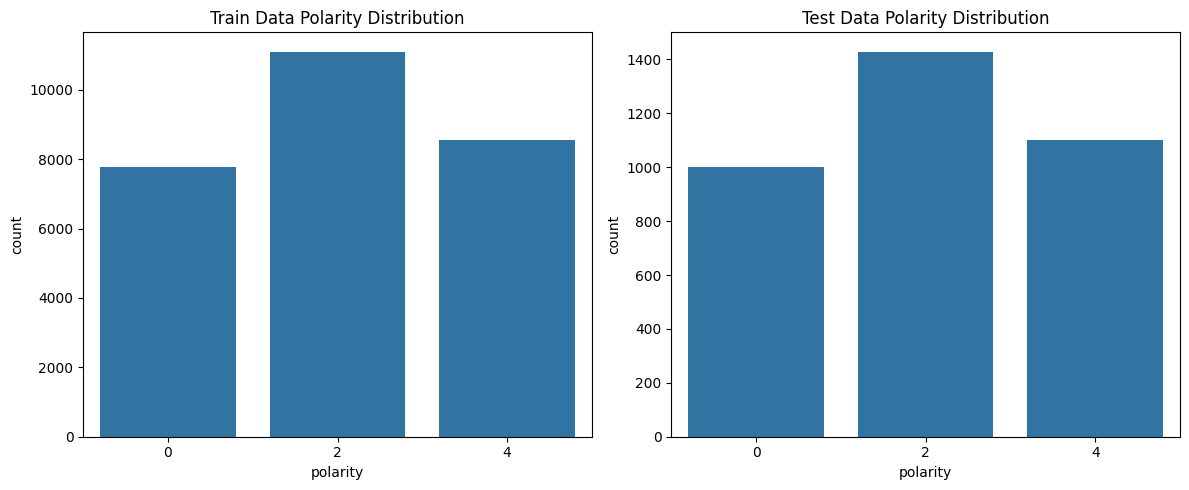

In [31]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train data polarity distribution
sns.countplot(data=_train, x="polarity", ax=axes[0])
axes[0].set_title("Train Data Polarity Distribution")

# Test data polarity distribution
sns.countplot(data=_test, x="polarity", ax=axes[1])
axes[1].set_title("Test Data Polarity Distribution")

plt.tight_layout()

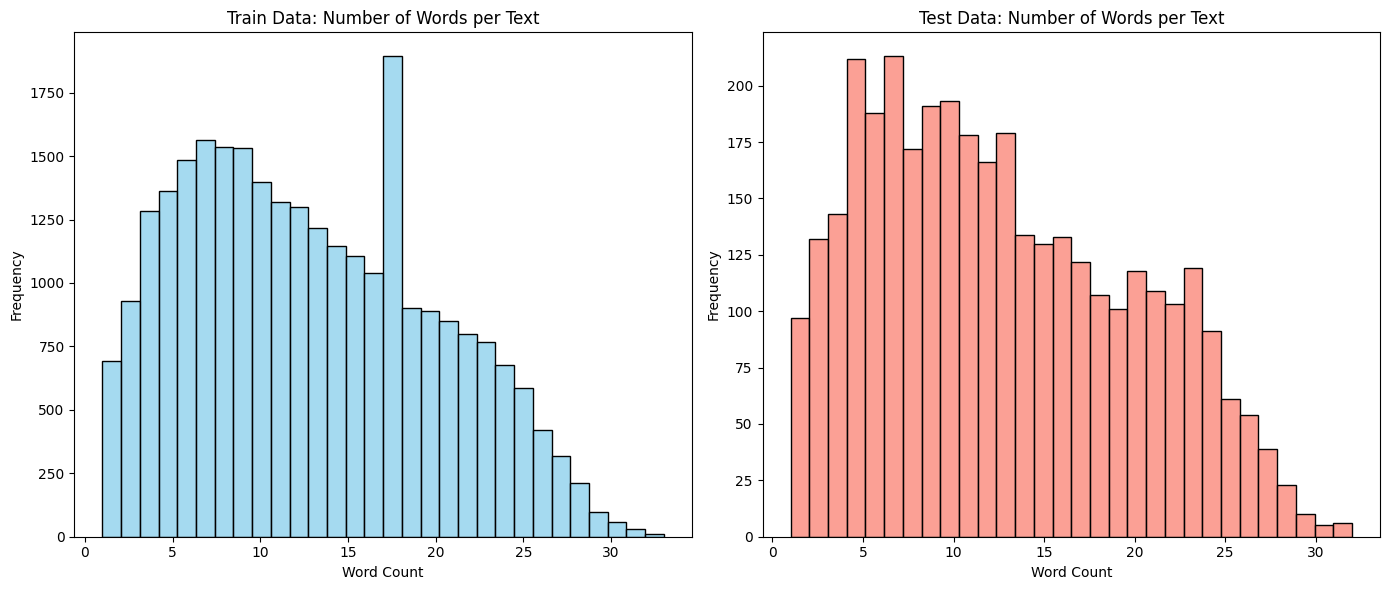

In [32]:
# Calculate word counts
train_word_counts = _train['text'].astype(str).apply(lambda x: len(x.split()))
test_word_counts = _test['text'].astype(str).apply(lambda x: len(x.split()))

# Create side-by-side histograms with separate y-axis scales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(train_word_counts, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Train Data: Number of Words per Text')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

sns.histplot(test_word_counts, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Test Data: Number of Words per Text')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

## NLP Preprocessing

In [39]:
# Load the SpaCy English model
# Since we are not using NER, we can disable it to speedup
nlp = spacy.load("en_core_web_sm", disable='ner')

def nlp_preprocess_text(texts):
    # lemmatize the tokens and store them in a list
    processed_texts = []
    for doc in nlp.pipe(texts, n_process=-1):
        lemmatized_tokens = [token.lemma_.lower() for token in doc if token.is_alpha and token.lemma_ not in nlp.Defaults.stop_words]
        
        # Join the lemmatized tokens into a string
        processed_text = " ".join(lemmatized_tokens)
        
        processed_texts.append(processed_text)
        
    return processed_texts

In [40]:
train_df['text'] = nlp_preprocess_text(train_df['text'])
test_df['text'] = nlp_preprocess_text(test_df['text'])

In [42]:
train_df.to_parquet('train_df_nlp_prepro.parquet', engine = 'fastparquet')
test_df.to_parquet('test_df_nlp_prepro.parquet', engine = 'fastparquet')

### TF-IDF

In [34]:
tfidf_ngram_vectorizer = TfidfVectorizer(min_df=0.001, ngram_range=(1, 3))
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(train_df["text"])
tfidf_ngram_vectorizer.get_feature_names_out()[150:160]
# tfidf_ngram_vectorizer_val = tfidf_ngram_vectorizer.transform(validation['user_review'])


array(['back to the', 'back to work', 'bad', 'bad for', 'badly', 'bag',
       'band', 'bank', 'bar', 'bb'], dtype=object)

In [ ]:
dense_vector = tfidf_ngram_vectorizer_train[0].toarray()
dense_vector.shape
# input should be 2094
# last layer 3

In [ ]:
import numpy as np
non_zero_indices = np.where(dense_vector[0] != 0)[0]
non_zero_values = dense_vector[0][non_zero_indices]
non_zero_values

In [ ]:
# converting the features_train and features_validation 
features_train = torch.tensor(features_train.toarray(), dtype=torch.float32)
features_validation = torch.tensor(features_validation.toarray(), dtype=torch.float32)

## Model + Training + Eval

In [ ]:
# convert target variables into pytorch tensors
y_train = torch.tensor(train['user_suggestion'])
y_validation = torch.tensor(validation['user_suggestion'])

In [ ]:
# initialise TensorDataset  object
train_dataset = TensorDataset(features_train, y_train)
val_dataset = TensorDataset(features_validation, y_validation)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [ ]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.fc3 = nn.Sigmoid() #softmax

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

In [ ]:
model = ANNModel(input_size=features_train.shape[1], hidden_size=64, output_size=1, dropout_rate=0.5)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels.float())  # Ensure labels are float
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels.float())  # Ensure labels are float
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# copy from module 4 of course 05

In [ ]:
def calculate_accuracy(loader):
    model.eval()  # Set the model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            predicted = outputs.squeeze() > 0.5  # Apply threshold to convert probabilities to binary predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy}%')
print(f'Validation Accuracy: {val_accuracy}%')